separation=5.0 Å  →  pofr=1.000000
separation=10.0 Å  →  pofr=1.000000
separation=15.0 Å  →  pofr=1.000000
separation=21.0 Å  →  pofr=1.000000
separation=22.0 Å  →  pofr=0.908796
separation=23.0 Å  →  pofr=0.713687
separation=24.0 Å  →  pofr=0.498685
separation=25.0 Å  →  pofr=0.310308
separation=26.0 Å  →  pofr=0.168686
separation=27.0 Å  →  pofr=0.076657
separation=28.0 Å  →  pofr=0.026595
separation=29.0 Å  →  pofr=0.005709
separation=30.0 Å  →  pofr=0.000385
separation=31.0 Å  →  pofr=0.000000
separation=40.0 Å  →  pofr=0.000000


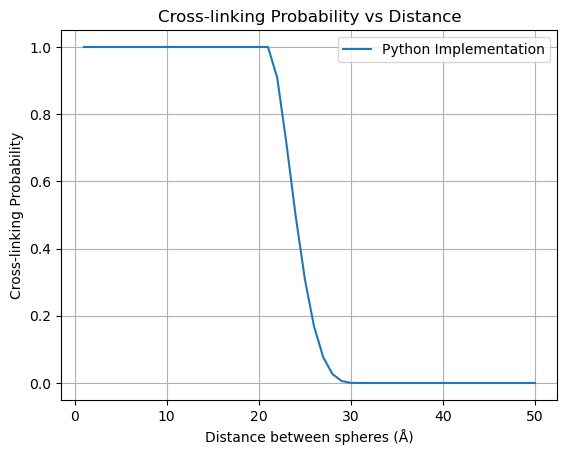

In [1]:
import IMP
import IMP.core
import IMP.isd
import IMP.test
import pickle
from random import sample
from math import pi, log, exp
import math
import numpy as np


def setupnuisance(m, initialvalue, minvalue, maxvalue, isoptimized=True):

    nuisance = IMP.isd.Scale.setup_particle(IMP.Particle(m), initialvalue)
    if minvalue:
        nuisance.set_lower(minvalue)
    if maxvalue:
        nuisance.set_upper(maxvalue)

    nuisance.set_is_optimized(nuisance.get_nuisance_key(), isoptimized)

    return nuisance


def make_test_restraint():
    m = IMP.Model()
    p1 = IMP.Particle(m)
    p2 = IMP.Particle(m)

    slope = 1.0
    length = 21.0

    xyz1 = IMP.core.XYZ.setup_particle(p1)
    xyz2 = IMP.core.XYZ.setup_particle(p2)

    xyz1.set_coordinates((0, 0, 0))
    xyz2.set_coordinates((10.0, 0, 0))

    sigma1 = setupnuisance(m, 5, 4.99, 5.01, False)
    sigma2 = setupnuisance(m, 5, 4.99, 5.01, False)
    psi = setupnuisance(m, 1.0, 1.0, 1.0, False)

    dr = IMP.isd.CrossLinkMSRestraint(m, length, slope)
    dr.set_weight(0.10)
    dr.set_name("test restraint")
    dr.add_contribution((p1, p2), (sigma1, sigma2), psi)
    return m, p1, p2, sigma1, sigma2, psi, dr

class CrossLinkMS:
    def __init__(self, length, slope):
        self.length = length
        self.slope = slope
        self.pairs = []

    def add_contribution(self, p1, p2, sigma1, sigma2, psi):
        self.pairs.append((p1, p2, sigma1, sigma2, psi))

    def sphere_cap(self, r1, r2, d):
        if d <= abs(r1 - r2):
            return min(4.0 / 3.0 * pi * r1**3,
                       4.0 / 3.0 * pi * r2**3)
        if d >= r1 + r2:
            return 0.0
        return (pi / (12.0 * d) * (r1 + r2 - d)**2 *
                (d*d + 2*d*r1 - 3*r1*r1 + 2*d*r2 + 6*r1*r2 - 3*r2*r2))

    def contributions(self):
        for p1, p2, s1, s2, psi in self.pairs:
            if p1 is not p2:
                dist = IMP.core.get_distance(IMP.core.XYZ(p1), IMP.core.XYZ(p2))
            else:
                dist = 36.0 / 35.0 * IMP.core.XYZR(p1).get_radius()
            dist = max(dist, 1e-4)
            sigmai, sigmaj = s1.get_scale(), s2.get_scale()
            voli = 4.0 / 3.0 * pi * sigmai**3
            volj = 4.0 / 3.0 * pi * sigmaj**3
            if dist < sigmai + sigmaj:
                xlvol = 4.0 / 3.0 * pi * (self.length / 2)**3
                fi = min(voli, xlvol)
                fj = min(volj, xlvol)
            else:
                di = dist - sigmaj - self.length / 2
                dj = dist - sigmai - self.length / 2
                fi = self.sphere_cap(sigmai, self.length / 2, abs(di))
                fj = self.sphere_cap(sigmaj, self.length / 2, abs(dj))
            pofr = fi * fj / (voli * volj)
            yield dist, pofr, psi.get_scale()

    def get_probability(self):
        onemprob = 1.0
        for dist, pofr, psi in self.contributions():
            onemprob *= (1.0 - (psi * (1.0 - pofr) + pofr * (1 - psi))
                         * math.exp(-self.slope * dist))
        return 1.0 - onemprob

m, p1, p2, sigma1, sigma2, psi, dr = make_test_restraint()

py_xl = CrossLinkMS(length=21.0, slope=1.0)
py_xl.add_contribution(p1, p2, sigma1, sigma2, psi)

# Just print pofr for different distances
xyz2 = IMP.core.XYZ(p2)
for sep in [5.0, 10.0, 15.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 40.0]:
    xyz2.set_coordinates((sep, 0, 0))
    for dist, pofr, psi_val in py_xl.contributions():
        print(f"separation={sep:.1f} Å  →  pofr={pofr:.6f}")
        
# plot the probability vs distance between the spheres
import matplotlib.pyplot as plt
distances = []
probabilities_cpp = []
probabilities_py = []
for sep in range(1, 51):
    xyz2.set_coordinates((sep, 0, 0))
    distances.append(sep)
    for dist, pofr, psi_val in py_xl.contributions():
        probabilities_py.append(pofr)
plt.plot(distances, probabilities_py, label='Python Implementation', linestyle='-')
plt.xlabel('Distance between spheres (Å)')
plt.ylabel('Cross-linking Probability')
plt.title('Cross-linking Probability vs Distance')
plt.legend()
plt.grid()
plt.show()

# Interactive version: visualize different separations
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def create_interactive_visualization(sigma1=5.0, sigma2=5.0, length=21.0):
    """
    Create interactive plot showing how probability changes with distance.
    """
    # Setup model
    m = IMP.Model()
    p1 = IMP.Particle(m)
    p2 = IMP.Particle(m)
    
    xyz1 = IMP.core.XYZ.setup_particle(p1)
    xyz2 = IMP.core.XYZ.setup_particle(p2)
    xyz1.set_coordinates((0, 0, 0))
    
    s1 = setupnuisance(m, sigma1, sigma1-0.01, sigma1+0.01, False)
    s2 = setupnuisance(m, sigma2, sigma2-0.01, sigma2+0.01, False)
    psi_particle = setupnuisance(m, 1.0, 1.0, 1.0, False)
    
    py_xl = CrossLinkMS(length=length, slope=1.0)
    py_xl.add_contribution(p1, p2, s1, s2, psi_particle)
    
    # Calculate probabilities for different distances
    distances = []
    probabilities = []
    
    for sep in np.linspace(0.5, 50, 100):
        xyz2.set_coordinates((sep, 0, 0))
        for dist, pofr, psi_val in py_xl.contributions():
            distances.append(sep)
            probabilities.append(pofr)
    
    # Create subplots: 3D view + probability curve
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'scatter3d'}, {'type': 'scatter'}]],
        subplot_titles=('3D Configuration', 'Probability vs Distance'),
        column_widths=[0.5, 0.5]
    )
    
    # Select a few representative distances to visualize
    representative_distances = [5.0, 10.0, 15.0, 21.0, 30.0, 40.0, 50.0]
    
    # Create frames for animation
    frames = []
    for sep in representative_distances:
        frame_data = []
        
        # Create spheres for this distance
        r1 = np.array([0, 0, 0])
        r2 = np.array([sep, 0, 0])
        
        # Sphere 1
        u = np.linspace(0, 2 * np.pi, 30)
        v = np.linspace(0, np.pi, 30)
        x1 = sigma1 * np.outer(np.cos(u), np.sin(v)) + r1[0]
        y1 = sigma1 * np.outer(np.sin(u), np.sin(v)) + r1[1]
        z1 = sigma1 * np.outer(np.ones(np.size(u)), np.cos(v)) + r1[2]
        
        frame_data.append(go.Surface(x=x1, y=y1, z=z1, 
                                    colorscale=[[0, 'blue'], [1, 'blue']],
                                    showscale=False, opacity=0.3))
        
        # Sphere 2
        x2 = sigma2 * np.outer(np.cos(u), np.sin(v)) + r2[0]
        y2 = sigma2 * np.outer(np.sin(u), np.sin(v)) + r2[1]
        z2 = sigma2 * np.outer(np.ones(np.size(u)), np.cos(v)) + r2[2]
        
        frame_data.append(go.Surface(x=x2, y=y2, z=z2,
                                    colorscale=[[0, 'red'], [1, 'red']],
                                    showscale=False, opacity=0.3))
        
        # Distance line
        frame_data.append(go.Scatter3d(
            x=[r1[0], r2[0]], y=[r1[1], r2[1]], z=[r1[2], r2[2]],
            mode='lines+markers',
            line=dict(color='green', width=5),
            marker=dict(size=5, color=['darkblue', 'darkred'])
        ))
        
        frames.append(go.Frame(data=frame_data, name=f'd={sep:.1f}'))
    
    # Initial configuration (d=10Å)
    r2_init = np.array([10, 0, 0])
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    
    x1 = sigma1 * np.outer(np.cos(u), np.sin(v))
    y1 = sigma1 * np.outer(np.sin(u), np.sin(v))
    z1 = sigma1 * np.outer(np.ones(np.size(u)), np.cos(v))
    
    fig.add_trace(go.Surface(x=x1, y=y1, z=z1,
                            colorscale=[[0, 'blue'], [1, 'blue']],
                            showscale=False, opacity=0.3,
                            name='Sphere 1'), row=1, col=1)
    
    x2 = sigma2 * np.outer(np.cos(u), np.sin(v)) + r2_init[0]
    y2 = sigma2 * np.outer(np.sin(u), np.sin(v)) + r2_init[1]
    z2 = sigma2 * np.outer(np.ones(np.size(u)), np.cos(v)) + r2_init[2]
    
    fig.add_trace(go.Surface(x=x2, y=y2, z=z2,
                            colorscale=[[0, 'red'], [1, 'red']],
                            showscale=False, opacity=0.3,
                            name='Sphere 2'), row=1, col=1)
    
    fig.add_trace(go.Scatter3d(
        x=[0, r2_init[0]], y=[0, r2_init[1]], z=[0, r2_init[2]],
        mode='lines+markers',
        line=dict(color='green', width=5),
        marker=dict(size=5, color=['darkblue', 'darkred']),
        name='Distance'), row=1, col=1)
    
    # Add probability curve
    fig.add_trace(go.Scatter(
        x=distances, y=probabilities,
        mode='lines',
        line=dict(color='purple', width=3),
        name='P(crosslink)'), row=1, col=2)
    
    # Add vertical line for crosslinker length
    fig.add_trace(go.Scatter(
        x=[length, length], y=[0, 1],
        mode='lines',
        line=dict(color='red', width=2, dash='dash'),
        name=f'L={length}Å'), row=1, col=2)
    
    # Update layout
    fig.update_layout(
        height=600,
        width=1400,
        title_text=f"Crosslinking Configuration Analysis (σ₁={sigma1:.1f}Å, σ₂={sigma2:.1f}Å, L={length:.1f}Å)",
        showlegend=True
    )
    
    fig.update_scenes(
        aspectmode='cube',
        xaxis=dict(title='X (Å)', range=[-20, 50]),
        yaxis=dict(title='Y (Å)', range=[-20, 20]),
        zaxis=dict(title='Z (Å)', range=[-20, 20])
    )
    
    fig.update_xaxes(title_text="Distance (Å)", row=1, col=2)
    fig.update_yaxes(title_text="Probability", range=[0, 1.05], row=1, col=2)
    
    return fig

# Create and show interactive visualization
fig_interactive = create_interactive_visualization(sigma1=5.0, sigma2=5.0, length=21.0)
fig_interactive.show()

import numpy as np
import matplotlib.pyplot as plt

# Your configuration
p1 = np.array([0.0, 0.0, 0.0])
p2 = np.array([25.0, 0.0, 0.0])
sigma1 = 6.0
sigma2 = 6.0
L = 21.0

# Monte Carlo sampling (TRUE probability)
N = 900000
q1_samples = np.random.normal(p1, sigma1, size=(N, 3))
q2_samples = np.random.normal(p2, sigma2, size=(N, 3))
distances = np.linalg.norm(q1_samples - q2_samples, axis=1)

prob_mc = np.mean(distances < L)


The logic of the IMP analytical formula relies on a specific geometric approximation to solve the "Convolution Problem."

Calculating the exact probability that two points, randomly sampled from two spheres, are within distance $L$ is mathematically complex (a 6D integral). To make this fast enough for scoring, IMP uses a **"Meeting in the Middle"** approximation.

Here is the detailed breakdown of the concepts and the logic:

### 1. The Core Concept: "Meeting in the Middle"
Instead of asking "Is distance $|p_1 - p_2| < L$?", the formula effectively asks:
*"Can particle 1 reach a midpoint, and can particle 2 reach the same midpoint, such that the total length is $L$?"*

It splits the crosslinker length $L$ into two halves ($L/2$). It then calculates the probability that:
1.  Particle 1 is within $L/2$ of the "interaction zone".
2.  Particle 2 is within $L/2$ of the "interaction zone".
3.  It assumes these two events are independent (which is the source of the approximation error).

### 2. The Spheres involved
*   **Uncertainty Sphere ($V_{sphere}$):**
    *   Radius: $\sigma$ (sigma).
    *   This represents the cloud of possible positions for the particle. The particle is uniformly distributed here.
    *   Volume: $V = \frac{4}{3}\pi \sigma^3$.
*   **Reachability Sphere ($V_{XL}$):**
    *   Radius: $L/2$.
    *   This represents the volume covered by half the crosslinker.

### 3. The Two Regimes

The code splits the logic into two physical scenarios based on the distance $d$ between the centers of the uncertainty spheres.

#### Case A: The "Saturated" Regime (Overlap)
**Condition:** `if d < sigma1 + sigma2`
*   **Logic:** The uncertainty spheres are physically crashing into each other.
*   **Assumption:** The limiting factor is no longer the distance between them, but simply the volume of the crosslinker itself.
*   **Calculation:**
    *   It compares the volume of the particle ($\sigma$) vs the volume of the crosslinker ($L/2$).
    *   `fi = min(voli, xlvol)`: If the crosslinker is smaller than the uncertainty cloud, the particle *must* be in that small crosslinker volume to work. If the crosslinker is huge, the entire uncertainty cloud is valid.
*   **The Flaw:** As you discovered, this logic assumes that if spheres overlap, they are perfectly concentric. It ignores the shape of the overlap. This is why you got $P=1.0$ in your test case—because the crosslinker volume ($L/2=10.5$) was larger than the particle volume ($\sigma=5$), so it assumed 100% of the particle volume was valid.

#### Case B: The "Reaching" Regime (Separated)
**Condition:** `else` (when spheres are apart)
*   **Logic:** The spheres are far apart. We need to calculate the volume of the "sliver" of the uncertainty sphere that is close enough to the other sphere to form a bridge.
*   **The Geometry:**
    1.  Imagine a line connecting Center 1 and Center 2.
    2.  The formula tries to place the "Reachability Sphere" (radius $L/2$) on this line, tangent to the *other* particle's uncertainty sphere.
    3.  `di` and `dj` represent the distance from the center of the Uncertainty Sphere to the center of this virtual Reachability Sphere.
*   **Spherical Cap:**
    *   When the Uncertainty Sphere (radius $\sigma$) and the Reachability Sphere (radius $L/2$) intersect, they form a lens shape.
    *   The **Spherical Cap** function calculates the volume of this intersection.
    *   This volume represents the specific subset of positions inside the uncertainty cloud where the particle is "close enough" to bridge the gap.

### 4. The Final Probability Formula
$$P = \frac{f_i}{V_i} \times \frac{f_j}{V_j}$$

*   $f_i$: The "Valid Volume" (Intersection of Uncertainty Sphere and Reachability Sphere).
*   $V_i$: The Total Volume of the Uncertainty Sphere.
*   $\frac{f_i}{V_i}$: The fraction of Particle 1's cloud that is capable of forming a crosslink.

By multiplying them, the formula says: *"The probability of a crosslink is the probability that Particle 1 is in its valid zone AND Particle 2 is in its valid zone."*

### Summary of Variables in Code
*   `sigmai`: Radius of the particle cloud.
*   `L/2`: Radius of the crosslinker reach.
*   `di`: Calculated distance between the particle center and the "virtual" crosslinker center.
*   `sphere_cap`: The mathematical function to get the volume of intersection between two spheres of different radii at distance `di`.

Computing probabilities (N=100000)...


Figure saved to output_figures/imp_vs_mc_sigma12.0_L21.0.pdf

Detailed Comparison Table:
--------------------------------------------------------------------------------
Distance (Å) |   IMP Prob |    MC Prob |
--------------------------------------------------------------------------------
         1.5 |   0.669922 |   1.000000 |
         2.5 |   0.669922 |   1.000000 |
         3.5 |   0.669922 |   1.000000 |
         4.5 |   0.669922 |   0.999990 |
         7.6 |   0.669922 |   0.989990 |
         9.6 |   0.669922 |   0.958730 |
        11.6 |   0.669922 |   0.897380 |
        14.6 |   0.669922 |   0.753260 |
        17.7 |   0.658544 |   0.580210 |
        19.7 |   0.576758 |   0.459760 |
        20.7 |   0.529169 |   0.397760 |
        20.7 |   0.529169 |   0.397760 |
        21.7 |   0.480874 |   0.350100 |
        22.7 |   0.432874 |   0.296210 |
        24.7 |   0.340076 |   0.202530 |
        29.8 |   0.124613 |   0.042150 |
        39.9 |   0.000000 |   0.000000 |
-----------

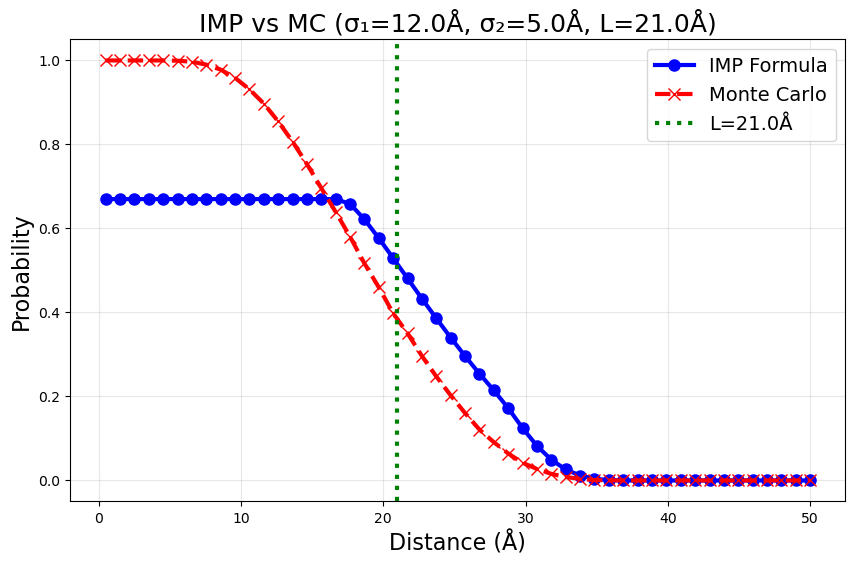

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import IMP
import IMP.core
from math import pi
import os

def compute_imp_probability(d, sigma1, sigma2, L):
    """
    Compute IMP analytical formula probability.
    
    Parameters:
    -----------
    d : float
        Distance between particle centers
    sigma1, sigma2 : float
        Uncertainty radii
    L : float
        Crosslinker maximum length
    """
    # Volumes
    vi = 4.0 / 3.0 * pi * sigma1**3
    vj = 4.0 / 3.0 * pi * sigma2**3
    
    # Sphere cap function
    def sphere_cap(r1, r2, dist):
        if dist <= abs(r1 - r2):
            return min(4.0 / 3.0 * pi * r1**3, 4.0 / 3.0 * pi * r2**3)
        if dist >= r1 + r2:
            return 0.0
        return (pi / (12.0 * dist) * (r1 + r2 - dist)**2 *
                (dist**2 + 2*dist*r1 - 3*r1**2 + 2*dist*r2 + 6*r1*r2 - 3*r2**2))
    
    # IMP formula logic
    if d < sigma1 + sigma2:
        xlvol = 4.0 / 3.0 * pi * (L / 2)**3
        fi = min(vi, xlvol)
        fj = min(vj, xlvol)
    else:
        di = d - sigma2 - L / 2
        dj = d - sigma1 - L / 2
        fi = sphere_cap(sigma1, L / 2, abs(di))
        fj = sphere_cap(sigma2, L / 2, abs(dj))
    
    pofr = fi * fj / (vi * vj)
    return pofr

def compute_mc_probability(p1, p2, sigma1, sigma2, L, N=100000):
    """
    Compute Monte Carlo probability by sampling uniformly within spheres.
    
    Parameters:
    -----------
    p1, p2 : np.ndarray
        Center positions of spheres
    sigma1, sigma2 : float
        Radii of uncertainty spheres
    L : float
        Crosslinker maximum length
    N : int
        Number of MC samples
    
    Returns:
    --------
    prob_mc : float
        Probability that distance < L
    """
    # Sample points uniformly within sphere 1
    # Method: Sample from uniform sphere using rejection sampling or inverse transform
    q1_samples = sample_uniform_sphere(p1, sigma1, N)
    q2_samples = sample_uniform_sphere(p2, sigma2, N)
    
    # Calculate pairwise distances
    distances = np.linalg.norm(q1_samples - q2_samples, axis=1)
    
    # Probability that distance < L
    prob_mc = np.mean(distances < L)
    return prob_mc

def sample_uniform_sphere(center, radius, N):
    """
    Sample points uniformly within a sphere using the standard method.
    More efficient than rejection sampling.
    
    Parameters:
    -----------
    center : np.ndarray, shape (3,)
        Center of sphere
    radius : float
        Radius of sphere
    N : int
        Number of samples needed
    
    Returns:
    --------
    samples : np.ndarray, shape (N, 3)
        Points uniformly distributed within sphere
    """
    # Sample radial distance: r^3 uniform -> r = radius * u^(1/3)
    u = np.random.uniform(0, 1, N)
    r = radius * u**(1/3)
    
    # Sample directions uniformly on sphere
    theta = np.random.uniform(0, 2*np.pi, N)  # Azimuthal angle
    phi = np.arccos(2*np.random.uniform(0, 1, N) - 1)  # Polar angle (uniform in cos)
    
    # Convert to Cartesian
    x = r * np.sin(phi) * np.cos(theta)
    y = r * np.sin(phi) * np.sin(theta)
    z = r * np.cos(phi)
    
    samples = np.column_stack((x, y, z)) + center
    return samples

import os
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go  # For interactive Plotly plot

def create_comparison_plot(sigma1=5.0, sigma2=5.0, L=21.0, N_mc=100000):
    """
    Simplified comparison plot: IMP vs Monte Carlo probabilities.
    Interactive Plotly plot displayed, Matplotlib used for PDF save.
    """
    distances = np.linspace(0.5, 50, 50)
    prob_imp = []
    prob_mc = []
    
    p1 = np.array([0.0, 0.0, 0.0])
    
    print(f"Computing probabilities (N={N_mc})...")
    for sep in distances:
        p2 = np.array([sep, 0.0, 0.0])
        prob_imp.append(compute_imp_probability(sep, sigma1, sigma2, L))
        prob_mc.append(compute_mc_probability(p1, p2, sigma1, sigma2, L, N=N_mc))
    
    # Create Plotly figure for interactive display
    fig_plotly = go.Figure()
    fig_plotly.add_trace(go.Scatter(x=distances, y=prob_imp, mode='lines+markers', name='IMP Formula', line=dict(color='blue', width=3), marker=dict(size=8)))
    fig_plotly.add_trace(go.Scatter(x=distances, y=prob_mc, mode='lines+markers', name='Monte Carlo', line=dict(color='red', width=3, dash='dash'), marker=dict(size=8, symbol='x')))
    fig_plotly.add_vline(x=L, line=dict(color='green', dash='dot', width=3), annotation_text=f'L={L}Å')
    fig_plotly.update_layout(
        title=f'IMP vs MC (σ₁={sigma1}Å, σ₂={sigma2}Å, L={L}Å)',
        xaxis_title='Distance (Å)',
        yaxis_title='Probability',
        font=dict(size=14)
    )
    fig_plotly.show()  # Display interactive Plotly plot
    
    # Create Matplotlib figure for PDF save
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(distances, prob_imp, 'o-', color='blue', linewidth=3, markersize=8, label='IMP Formula')
    ax.plot(distances, prob_mc, 'x--', color='red', linewidth=3, markersize=8, label='Monte Carlo')
    ax.axvline(x=L, color='green', linestyle=':', linewidth=3, label=f'L={L}Å')
    ax.set_xlabel('Distance (Å)', fontsize=16)
    ax.set_ylabel('Probability', fontsize=16)
    ax.set_title(f'IMP vs MC (σ₁={sigma1}Å, σ₂={sigma2}Å, L={L}Å)', fontsize=18)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Ensure output directory exists
    if not os.path.exists("output_figures"):
        os.makedirs("output_figures")
    
    # Save as PDF
    filename = f"output_figures/imp_vs_mc_sigma{sigma1}_L{L}.pdf"
    fig.savefig(filename, bbox_inches='tight')
    print(f"Figure saved to {filename}")
    
    return fig, {
        'distances': distances, 
        'prob_imp': np.array(prob_imp), 
        'prob_mc': np.array(prob_mc)
    }
    
# Example usage (same as before)
fig_comparison, results = create_comparison_plot(
    sigma1=12.0, 
    sigma2=5.0, 
    L=21.0, 
    N_mc=100000
)

#fig_comparison.show()

# Detailed table
print("\nDetailed Comparison Table:")
print("-" * 80)
print(f"{'Distance (Å)':>12} | {'IMP Prob':>10} | {'MC Prob':>10} |")
print("-" * 80)

test_distances = [2.0, 3.0, 4.0, 5.0, 8.0, 10.0, 12.0, 15.0, 18.0, 20.0, 20.5, 21.0, 22.0, 23.0, 25.0, 30.0, 40.0]
for test_d in test_distances:
    idx = np.argmin(np.abs(results['distances'] - test_d))
    actual_d = results['distances'][idx]
    p_imp = results['prob_imp'][idx]
    p_mc = results['prob_mc'][idx]
    
    print(f"{actual_d:12.1f} | {p_imp:10.6f} | {p_mc:10.6f} |")

print("-" * 80)

Figure saved to output_figures/radius_sweep_d19.0_L21.0.pdf


{'sigma': array([ 0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,
         6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. ,
        11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5,
        17. , 17.5, 18. , 18.5, 19. , 19.5, 20. ]),
 'prob_imp': array([1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 0.75644905, 0.57936033, 0.44879532, 0.35129803,
        0.27763594, 0.22137735, 0.17797852, 0.14418756, 0.117649  ,
        0.09663748, 0.07987592, 0.06640979, 0.05551908, 0.046656  ,
        0.03940041, 0.03342762, 0.02848487, 0.02437407, 0.02093899]),
 'prob_mc': array([1.     , 1.     , 0.98456, 0.9328 , 0.87566, 0.82146, 0.77372,
        0.73342, 0.69642, 0.67058, 0.64322, 0.61868, 0.5993 , 0.58774,
      

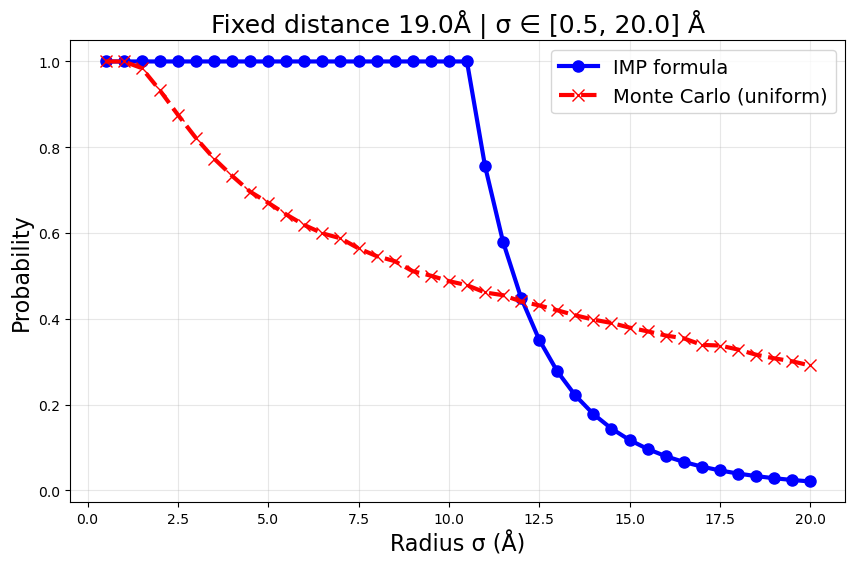

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go  # For interactive Plotly plot

def create_radius_sweep_plot(
    distance=35.0,
    sigma_min=2.0,
    sigma_max=30.0,
    steps=29,
    L=21.0,
    N_mc=500000
):
    """
    Compare IMP vs uniform Monte Carlo probabilities as the sphere radius grows.
    Interactive Plotly plot displayed, Matplotlib used for PDF save.
    """
    sigma_values = np.linspace(sigma_min, sigma_max, steps)
    prob_imp = []
    prob_mc = []
    p1 = np.array([0.0, 0.0, 0.0])
    p2 = np.array([distance, 0.0, 0.0])

    for sigma in sigma_values:
        prob_imp.append(compute_imp_probability(distance, sigma, sigma, L))
        prob_mc.append(compute_mc_probability(p1, p2, sigma, sigma, L, N=N_mc))

    # Create Plotly figure for interactive display
    fig_plotly = go.Figure()
    fig_plotly.add_trace(go.Scatter(x=sigma_values, y=prob_imp, mode='lines+markers', name='IMP formula', line=dict(color='blue', width=3), marker=dict(size=8)))
    fig_plotly.add_trace(go.Scatter(x=sigma_values, y=prob_mc, mode='lines+markers', name='Monte Carlo (uniform)', line=dict(color='red', width=3, dash='dash'), marker=dict(size=8, symbol='x')))
    fig_plotly.update_layout(
        title=f'Fixed distance {distance:.1f}Å | σ ∈ [{sigma_min:.1f}, {sigma_max:.1f}] Å',
        xaxis_title='Radius σ (Å)',
        yaxis_title='Probability',
        font=dict(size=14)
    )
    fig_plotly.show()  # Display interactive Plotly plot
    
    # Create Matplotlib figure for PDF save
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(sigma_values, prob_imp, 'o-', color='blue', linewidth=3, markersize=8, label='IMP formula')
    ax.plot(sigma_values, prob_mc, 'x--', color='red', linewidth=3, markersize=8, label='Monte Carlo (uniform)')
    ax.set_xlabel('Radius σ (Å)', fontsize=16)
    ax.set_ylabel('Probability', fontsize=16)
    ax.set_title(f'Fixed distance {distance:.1f}Å | σ ∈ [{sigma_min:.1f}, {sigma_max:.1f}] Å', fontsize=18)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Ensure output directory exists
    if not os.path.exists("output_figures"):
        os.makedirs("output_figures")
        
    # Save as PDF
    filename = f"output_figures/radius_sweep_d{distance}_L{L}.pdf"
    fig.savefig(filename, bbox_inches='tight')
    print(f"Figure saved to {filename}")
    
    return {"sigma": sigma_values, "prob_imp": np.array(prob_imp), "prob_mc": np.array(prob_mc)}

# example usage
create_radius_sweep_plot(distance=19.0, sigma_min=0.5, sigma_max=20.0, steps=40, L=21.0, N_mc=50000)

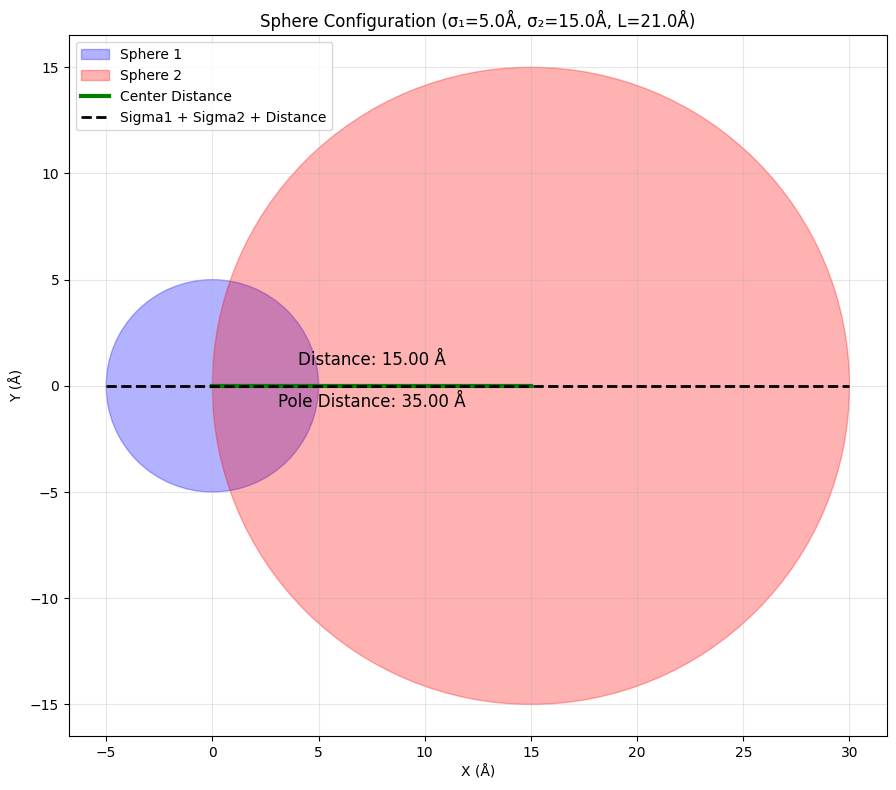

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def plot_configuration(p1, p2, sigma1, sigma2, L):
    """
    Plot 2D projection of spheres as circles, with distance lines and annotations.
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Draw circles for spheres (projections)
    circle1 = plt.Circle(p1[:2], sigma1, color='blue', alpha=0.3, label='Sphere 1')
    circle2 = plt.Circle(p2[:2], sigma2, color='red', alpha=0.3, label='Sphere 2')
    ax.add_patch(circle1)
    ax.add_patch(circle2)
    
    # Line joining centers
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'g-', linewidth=3, label='Center Distance')
    
    # Calculate distances
    dist_centers = np.linalg.norm(p2 - p1)
    dist_poles = dist_centers + (sigma1 + sigma2)
    
    # Annotations
    mid_x = (p1[0] + p2[0]) / 2
    mid_y = (p1[1] + p2[1]) / 2
    ax.text(mid_x, mid_y + 1, f'Distance: {dist_centers:.2f} Å', ha='center', fontsize=12)
    ax.text(mid_x, mid_y - 1, f'Pole Distance: {dist_poles:.2f} Å', ha='center', fontsize=12)
    
    # Optional: lines for sigma1 + sigma2
    # Extend the line beyond the centers by sigma1 and sigma2
    dir_vec = (p2 - p1) / dist_centers
    start = p1 - sigma1 * dir_vec
    end = p2 + sigma2 * dir_vec
    ax.plot([start[0], end[0]], [start[1], end[1]], 'k--', linewidth=2, label='Sigma1 + Sigma2 + Distance')
    
    # Set equal aspect ratio
    ax.set_aspect('equal')
    ax.set_xlabel('X (Å)')
    ax.set_ylabel('Y (Å)')
    ax.set_title(f'Sphere Configuration (σ₁={sigma1}Å, σ₂={sigma2}Å, L={L}Å)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage
p1 = np.array([0.0, 0.0, 0.0])
p2 = np.array([15.0, 0.0, 0.0])
sigma1 = 5.0
sigma2 = 15.0
L = 21.0
plot_configuration(p1, p2, sigma1, sigma2, L)